In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_pickle("../Data/countries_clean.plk")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   192 non-null    object 
 1   Capital                   192 non-null    object 
 2   Constitutional_Form       192 non-null    object 
 3   Religion                  192 non-null    object 
 4   Democracy_Score           192 non-null    float64
 5   Democracy_Classification  192 non-null    object 
 6   Development_Status        192 non-null    object 
 7   Latitude                  192 non-null    float64
 8   Longitude                 192 non-null    float64
 9   Area                      192 non-null    int64  
 10  Population                192 non-null    int64  
 11  GDP                       192 non-null    int64  
 12  %Agriculture              192 non-null    float64
 13  GDP_CAPITA                192 non-null    float64
 14  Life_exp  

In [4]:
df.columns

Index(['Country', 'Capital', 'Constitutional_Form', 'Religion',
       'Democracy_Score', 'Democracy_Classification', 'Development_Status',
       'Latitude', 'Longitude', 'Area', 'Population', 'GDP', '%Agriculture',
       'GDP_CAPITA', 'Life_exp', 'lat_pos', 'lon_pos', 'Equatorial',
       'Agriculture_Flag', 'Continent', 'Population_Density', 'Region',
       'Landlocked', 'GDP_per_Area', 'Income_Level', 'Life_Exp_Category'],
      dtype='object')

In [5]:
df['Development_Status'] = pd.get_dummies(df['Development_Status'], drop_first=True, dtype=int)

In [6]:
df = df.rename(columns={'Development_Status': 'Developing_Country'})
df

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Developing_Country,Latitude,Longitude,Area,...,lon_pos,Equatorial,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category
0,Afghanistan,Kabul,Islamic Republic (Provisional),Islam,0.25,Authoritarian,1,34.5328,69.1658,652230,...,North,No,Yes,Asia,63.1,South Asia,Yes,29286,Low,Low
1,Albania,Tirana,Parliamentary Republic,Islam,6.20,Flawed Democracy,1,41.3289,19.8178,28748,...,North,No,Yes,Europe,96.6,Central Europe,No,531448,Upper-Middle,High
2,Algeria,Algiers,Presidential Republic,Islam,3.55,Authoritarian,1,36.7764,3.0586,2381741,...,North,No,No,Africa,18.9,North Africa,No,71371,Lower-Middle,High
3,Andorra,Andorra la Vella,Parliamentary Co-Principality,Christianity,8.61,Full Democracy,0,42.5000,1.5200,468,...,North,No,Yes,Europe,170.6,Western Europe,Yes,6739440,High,High
4,Angola,Luanda,Presidential Republic,Christianity,4.05,Hybrid Regime,1,-8.8383,13.2344,1246700,...,South,Yes,Yes,Africa,28.5,East Africa,No,75909,Lower-Middle,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Venezuela,Caracas,Federal Presidential Republic,Christianity,2.25,Authoritarian,1,10.5000,-66.9333,912050,...,North,Yes,Yes,South America,31,Northern South America,No,528874,High,Medium
188,Vietnam,Hanoi,One-Party Socialist Republic,Unaffiliated,2.62,Authoritarian,1,21.0300,105.8500,331690,...,North,Yes,Yes,Asia,296,Southeast Asia,No,789657,Lower-Middle,High
189,Yemen,Sanaa,Provisional Government,Islam,1.95,Authoritarian,1,15.3500,44.2100,555000,...,North,Yes,Yes,Asia,60.7,Western Asia/Middle East,No,48494,Low,Medium
190,Zambia,Lusaka,Presidential Republic,Christianity,5.73,Hybrid Regime,1,-15.4167,28.2833,752618,...,South,Yes,Yes,Africa,26.6,Southern Africa,Yes,30646,Lower-Middle,Low


In [7]:
df_selected_cols = pd.get_dummies(df[['Developing_Country','Life_exp', 'Equatorial']],drop_first=True,dtype=int)

In [8]:
y = df_selected_cols.iloc[:,0]
X = df_selected_cols.iloc[:,1:]

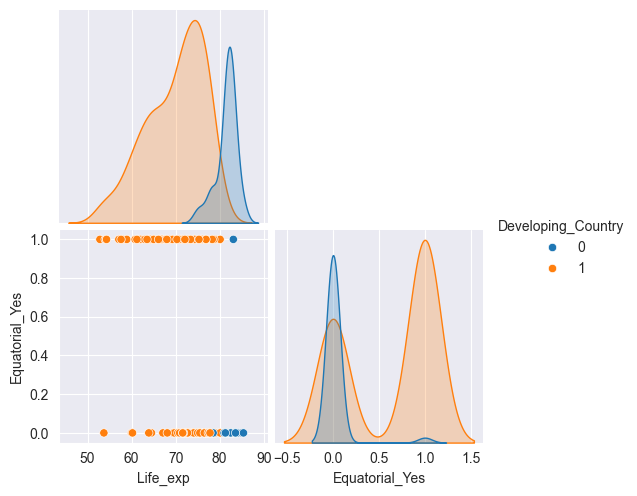

In [9]:
sns.pairplot(df_selected_cols,corner=True,hue='Developing_Country');

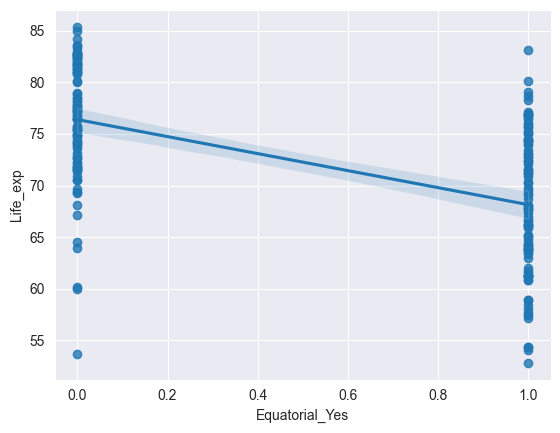

In [10]:
sns.regplot(data=df_selected_cols, x='Equatorial_Yes', y= 'Life_exp');

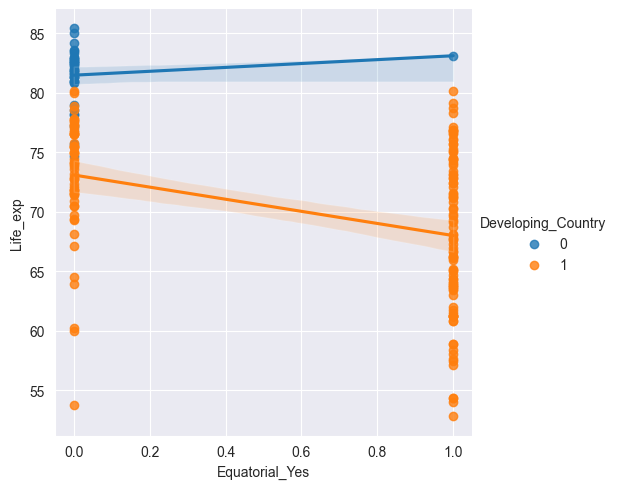

In [11]:
sns.lmplot(data=df_selected_cols, x='Equatorial_Yes', y= 'Life_exp', hue='Developing_Country' );

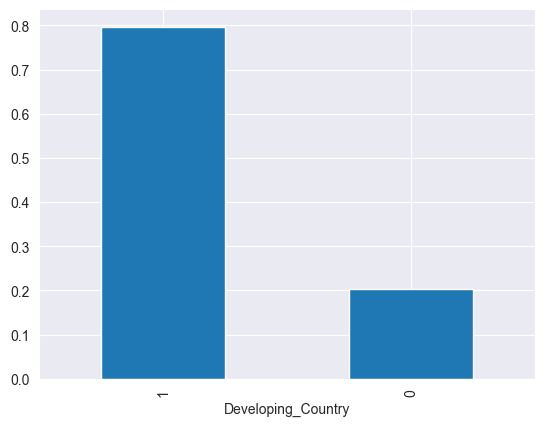

In [12]:



df.Developing_Country.value_counts(normalize=True).plot.bar();

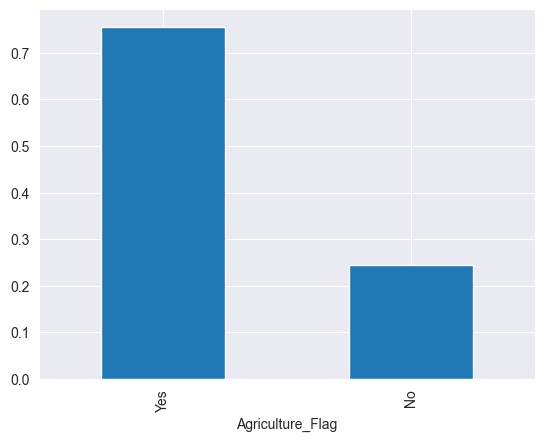

In [13]:
df.Agriculture_Flag.value_counts(normalize=True).plot.bar();

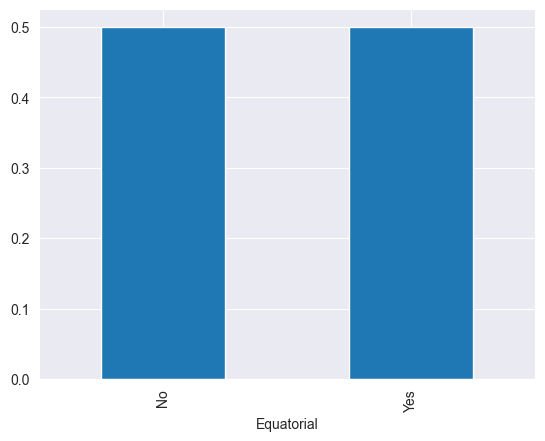

In [14]:
df.Equatorial.value_counts(normalize=True).plot.bar();

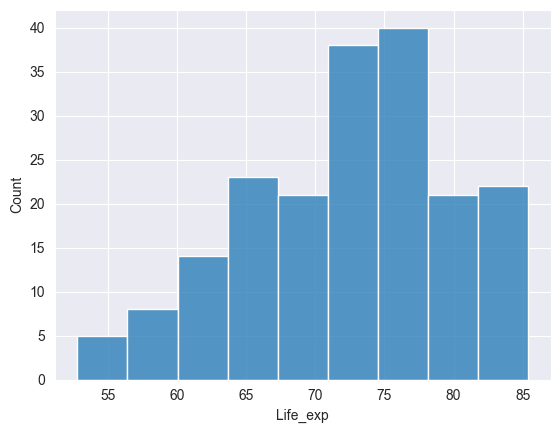

In [15]:
sns.histplot(df.Life_exp);

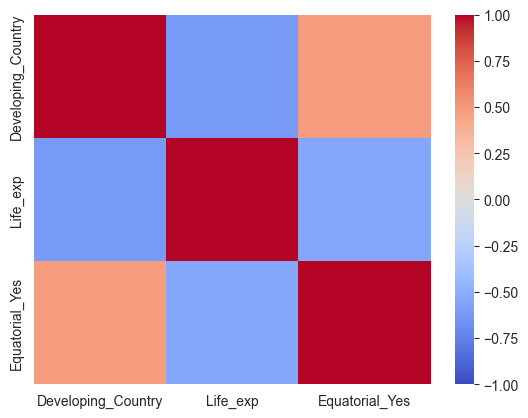

In [16]:
sns.heatmap(df_selected_cols.corr(),vmin=-1,vmax=1,cmap='coolwarm');

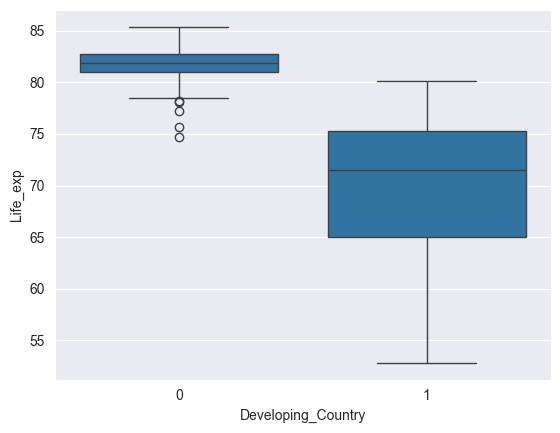

In [17]:
sns.boxplot(df_selected_cols, x='Developing_Country', y='Life_exp');

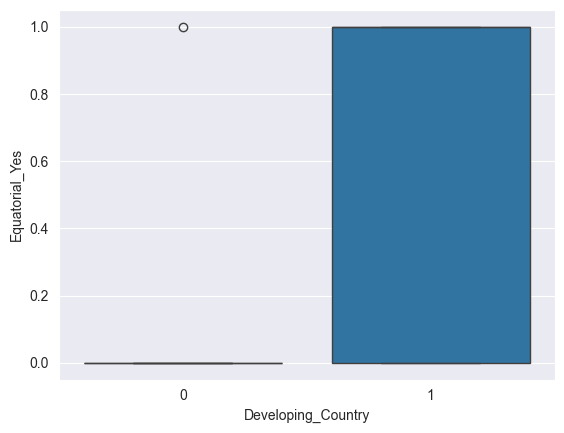

In [18]:
sns.boxplot(df_selected_cols, x='Developing_Country', y='Equatorial_Yes');

In [19]:
df_selected_cols.groupby('Developing_Country')['Equatorial_Yes'].sum()

Developing_Country
0     1
1    95
Name: Equatorial_Yes, dtype: int32

In [20]:
df_selected_cols.query(
    "Developing_Country == 0 and Equatorial_Yes == 1"
)

,Developing_Country,Life_exp,Equatorial_Yes
153,0,83.1,1


In [21]:
df.loc[153]

Country                                  Singapore
Capital                                  Singapore
Constitutional_Form         Parliamentary Republic
Religion                                  Buddhism
Democracy_Score                               6.18
Democracy_Classification          Flawed Democracy
Developing_Country                               0
Latitude                                      1.29
Longitude                                   103.85
Area                                           719
Population                                 5637022
GDP                                   372062527489
%Agriculture                                  0.01
GDP_CAPITA                                66003.38
Life_exp                                      83.1
lat_pos                                       East
lon_pos                                      North
Equatorial                                     Yes
Agriculture_Flag                                No
Continent                      

In [22]:
df_selected_cols.query("Developing_Country == 0 and Life_exp < 78" )

,Developing_Country,Life_exp,Equatorial_Yes
92,0,74.7,0
98,0,75.7,0
154,0,77.2,0


In [23]:
df.loc[[92,98,154]]

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Developing_Country,Latitude,Longitude,Area,...,lon_pos,Equatorial,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category
92,Latvia,Riga,Parliamentary Republic,Christianity,7.66,Flawed Democracy,0,56.9475,24.1069,64594,...,North,No,Yes,Europe,29.2,Northern Europe,No,528179,High,Medium
98,Lithuania,Vilnius,Semi-Presidential Republic,Christianity,7.59,Flawed Democracy,0,54.6872,25.2800,65300,...,North,No,Yes,Europe,43.4,Eastern Europe,No,830311,High,High
154,Slovakia,Bratislava,Parliamentary Republic,Christianity,7.21,Flawed Democracy,0,48.1447,17.1128,49035,...,North,No,Yes,Europe,110.8,Central Europe,Yes,2149940,High,High


<Axes: xlabel='Equatorial_Yes', ylabel='Life_exp'>

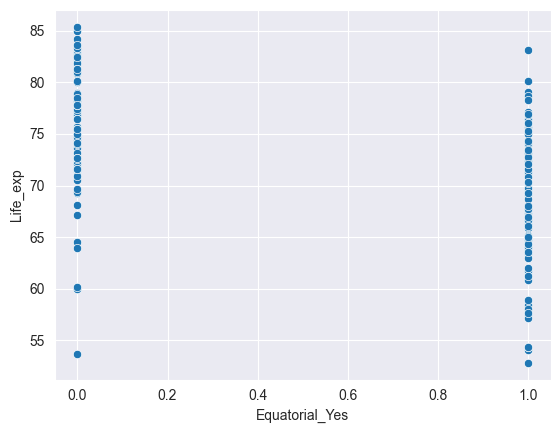

In [24]:
sns.scatterplot(df_selected_cols, x='Equatorial_Yes', y='Life_exp')

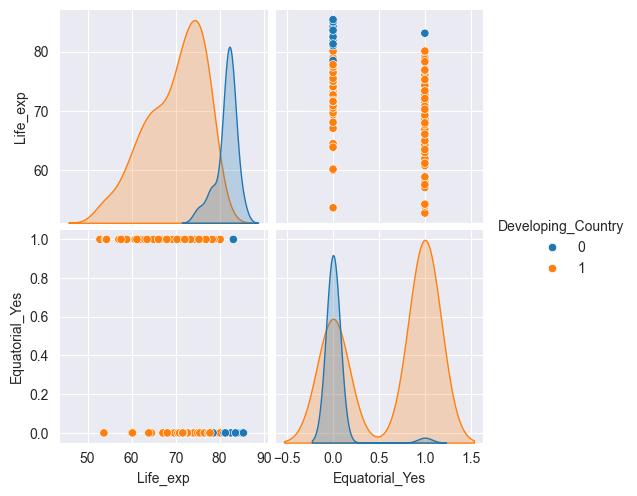

In [25]:
sns.pairplot(df_selected_cols,hue='Developing_Country');

In [26]:
df_selected_cols.query("Developing_Country == 1 and Equatorial_Yes == 0" ).sum()

Developing_Country      58.0
Life_exp              4238.4
Equatorial_Yes           0.0
dtype: float64

In [27]:
df_selected_cols

,Developing_Country,Life_exp,Equatorial_Yes
0,1,64.5,0
1,1,78.5,0
2,1,76.7,0
3,0,83.5,0
4,1,60.8,1
...,...,...,...
187,1,72.1,1
188,1,75.3,1
189,1,66.1,1
190,1,63.5,1


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
y = df_selected_cols.Developing_Country

In [30]:
X = df_selected_cols.iloc[:,1:]

In [31]:
X_train, y_train, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
X_train.shape

(153, 2)

In [33]:
y.shape

(192,)

In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

In [35]:
X_train_std = std.fit_transform(X_train)


In [36]:
from sklearn.neighbors import KNeighborsClassifier

k=5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_std, y_train)


KNeighborsClassifier()

In [37]:
from pycaret.classification import *

In [38]:
s = setup(df_selected_cols, target='Developing_Country')

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\Lenovo\miniconda3\envs\py311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9549,0.9848,0.9818,0.9644,0.9714,0.8551,0.8713,0.0810
gbc,Gradient Boosting Classifier,0.9549,0.9811,0.9818,0.9644,0.9714,0.8551,0.8713,0.0890
et,Extra Trees Classifier,0.9549,0.9355,0.9818,0.9644,0.9714,0.8551,0.8713,0.1160
rf,Random Forest Classifier,0.9473,0.9800,0.9718,0.9635,0.9661,0.8363,0.8501,0.1380
catboost,CatBoost Classifier,0.9473,0.9921,0.9727,0.9644,0.9666,0.8306,0.8492,1.0850
lr,Logistic Regression,0.9467,0.9855,0.9727,0.9636,0.9671,0.8239,0.8349,1.8200
lda,Linear Discriminant Analysis,0.9467,0.9921,0.9727,0.9636,0.9671,0.8239,0.8349,0.0200
dt,Decision Tree Classifier,0.9407,0.9159,0.9636,0.9644,0.9614,0.8210,0.8414,0.0280
knn,K Neighbors Classifier,0.9396,0.9771,0.9636,0.9636,0.9619,0.8086,0.8224,0.0440
ridge,Ridge Classifier,0.9390,0.9921,0.9909,0.9409,0.9636,0.7766,0.8070,0.0330


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=1435)

In [ ]:
create_model('rf')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:28:37
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Random Forest Classifier


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8571,1.0000,0.8182,1.0000,0.9000,0.6585,0.7006
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.9231,1.0000,1.0000,0.9167,0.9565,0.6286,0.6770
7,0.9231,0.8333,1.0000,0.9091,0.9524,0.7547,0.7785
8,0.8462,0.9667,0.9000,0.9000,0.9000,0.5667,0.5667


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=1435, verbose=0,
                       warm_start=False)